In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split

In [72]:
import pandas as pd

url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'

column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight', 
                'Acceleration', 'Model Year', 'Origin', 'Car Name']

# Use regex to split by whitespace, but keep quoted car names together
dataset = pd.read_csv(
    url,
    names=column_names,
    na_values='?',
    comment='\t',
    sep=r'\s+(?=(?:[^"]*"[^"]*")*[^"]*$)',
    engine='python'
  
)

# Convert Horsepower to numeric
#dataset['Horsepower'] = pd.to_numeric(dataset['Horsepower'], errors='coerce')

# Drop rows with missing values
#dataset = dataset.dropna()

In [73]:
dataset.head(5)

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin,Car Name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,"""chevrolet chevelle malibu"""
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,"""buick skylark 320"""
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,"""plymouth satellite"""
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,"""amc rebel sst"""
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,"""ford torino"""


In [74]:
print(dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           398 non-null    float64
 1   Cylinders     398 non-null    int64  
 2   Displacement  398 non-null    float64
 3   Horsepower    392 non-null    float64
 4   Weight        398 non-null    float64
 5   Acceleration  398 non-null    float64
 6   Model Year    398 non-null    int64  
 7   Origin        398 non-null    int64  
 8   Car Name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB
None


### Step 1: Check for missing data

In [75]:
print(dataset.isna().sum())

MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Origin          0
Car Name        0
dtype: int64


### Step 2: Handle missing data

In [76]:
# Drop rows with missing values
dataset = dataset.dropna()

# Confirm there are no more missing values
print(dataset.isna().sum())

MPG             0
Cylinders       0
Displacement    0
Horsepower      0
Weight          0
Acceleration    0
Model Year      0
Origin          0
Car Name        0
dtype: int64


### Inspect the Origin column

In [77]:
print(dataset['Origin'].value_counts())

Origin
1    245
3     79
2     68
Name: count, dtype: int64


### One-hot encode Origin

In [40]:
# Step 1: create dummies
origin_dummies = pd.get_dummies(dataset['Origin'], prefix='Origin')

# Step 2: drop original 'Origin' column
dataset = dataset.drop('Origin', axis=1)

# Step 3: attach dummies
dataset = pd.concat([dataset, origin_dummies], axis=1)


In [41]:
dataset.head(3)

,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Car Name,Origin_1,Origin_2,Origin_3
MPG,,,,,,,,,,
18.0,8,307.0,130.0,3504.0,12.0,70,"""chevrolet chevelle malibu""",True,False,False
15.0,8,350.0,165.0,3693.0,11.5,70,"""buick skylark 320""",True,False,False
18.0,8,318.0,150.0,3436.0,11.0,70,"""plymouth satellite""",True,False,False


In [78]:
dataset['Origin'] = dataset['Origin'].map({1:'USA', 2:'Europe', 3:'Japan'})
origin_dummies = pd.get_dummies(dataset['Origin'], prefix='Origin')
dataset = pd.concat([dataset.drop('Origin', axis=1), origin_dummies], axis=1)



In [79]:
dataset.head(3)

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Car Name,Origin_Europe,Origin_Japan,Origin_USA
0,18.0,8,307.0,130.0,3504.0,12.0,70,"""chevrolet chevelle malibu""",False,False,True
1,15.0,8,350.0,165.0,3693.0,11.5,70,"""buick skylark 320""",False,False,True
2,18.0,8,318.0,150.0,3436.0,11.0,70,"""plymouth satellite""",False,False,True


### data inspection and preprocessing

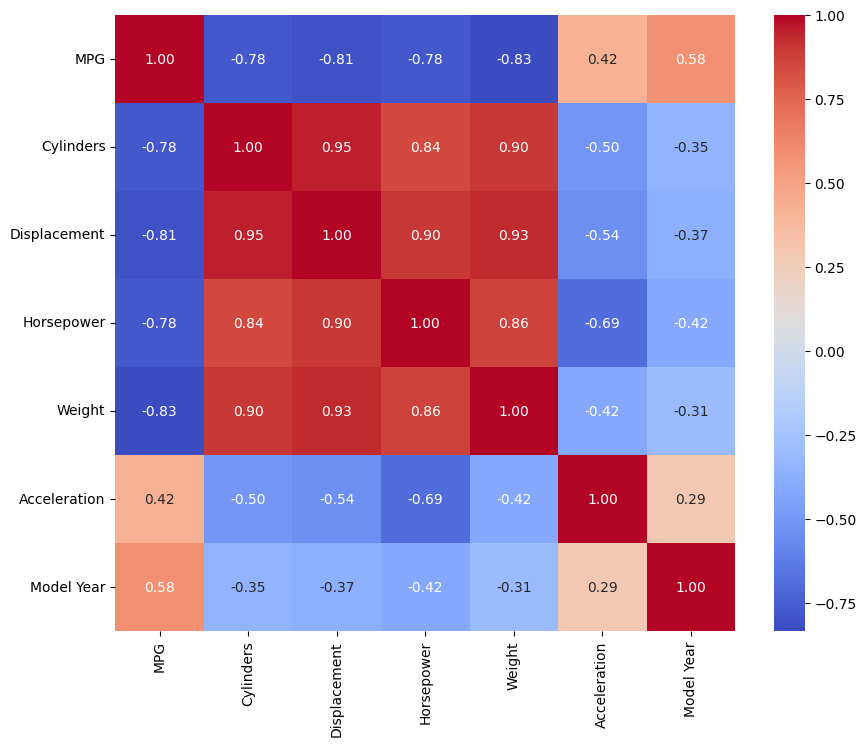

In [80]:

corr_matrix = dataset.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [81]:
print(dataset.dtypes)

MPG              float64
Cylinders          int64
Displacement     float64
Horsepower       float64
Weight           float64
Acceleration     float64
Model Year         int64
Car Name          object
Origin_Europe       bool
Origin_Japan        bool
Origin_USA          bool
dtype: object


In [82]:
numeric_features = dataset.drop('Car Name', axis=1)

### Standardize the numeric features

In [83]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
dataset_scaled = pd.DataFrame(scaler.fit_transform(numeric_features), columns=numeric_features.columns)



In [84]:
y = dataset_scaled ['MPG']
X = dataset_scaled.drop('MPG', axis=1)

## train and test sets

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [86]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Fit on training data and transform both train and test
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)


## Build the linear regression model

In [87]:
input_dim = X_train_scaled.shape[1]

In [88]:
print(input_dim)

9


In [89]:
inputs = Input(shape=(input_dim,))
outputs = Dense(1)(inputs)


2026-02-01 17:49:58.428113: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-02-01 17:49:58.428326: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-02-01 17:49:58.428357: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2026-02-01 17:49:58.428596: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-01 17:49:58.428621: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [92]:
linear_model = Model(inputs, outputs)

In [93]:
linear_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10 (40.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

## Compile the model

In [94]:
opt = tf.optimizers.Adam(learning_rate=0.1)
linear_model.compile(loss="mean_absolute_error", optimizer= opt, metrics=['mae'])

In [96]:
y_scaler = MinMaxScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1,1))

linear_history = linear_model.fit(X_train_scaled, y_train_scaled, epochs=100, batch_size=32, validation_split=0.2)

Epoch 1/100


2026-02-01 18:11:07.750146: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.3044 - mae: 0.3044 - val_loss: 0.1580 - val_mae: 0.1580
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1950 - mae: 0.1950 - val_loss: 0.1629 - val_mae: 0.1629
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1191 - mae: 0.1191 - val_loss: 0.1262 - val_mae: 0.1262
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0967 - mae: 0.0967 - val_loss: 0.0769 - val_mae: 0.0769
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0996 - mae: 0.0996 - val_loss: 0.1119 - val_mae: 0.1119
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0969 - mae: 0.0969 - val_loss: 0.0812 - val_mae: 0.0812
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0885 - mae: 0.0885 - val_loss: 0.0910 - val_mae: 0.0910
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0789 - mae: 0.0789 - val_loss: 0.0647 - val_mae: 0.0647
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0758 - mae: 0.0758 - val_loss: 0

In [98]:
history = linear_history.history

In [99]:
history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

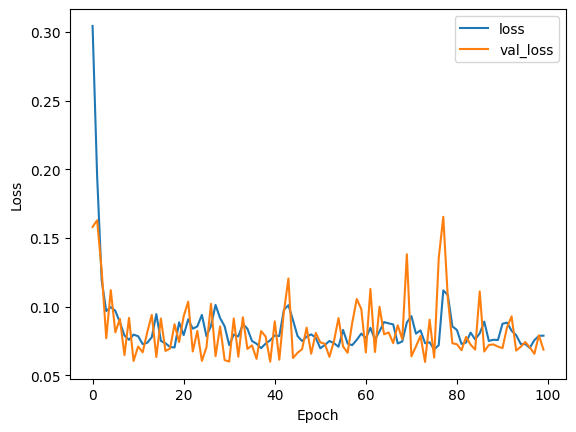

In [100]:
loss = history['loss']
mae = history['mae']
val_loss = history['val_loss']
val_mae = history['val_mae']

plt.plot(loss, label ='loss')
plt.plot(val_loss, label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

In [101]:
test_results = {}
test_results['linear_model'] = linear_model.evaluate(X_test_scaled, y_test_scaled, verbose=0)


## Second Model 

In [103]:
inputs = Input(shape=(input_dim,))

# First hidden layer: 64 neurons, ReLU activation
x = Dense(64, activation='relu')(inputs)

# Second hidden layer: 64 neurons, ReLU activation
x = Dense(64, activation='relu')(x)

# Output layer: 1 neuron, no activation (for regression)
outputs = Dense(1)(x)

# Create the model
dn_model = Model(inputs=inputs, outputs=outputs)

In [105]:
dn_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,865 (19.00 KB)

 Trainable params: 4,865 (19.00 KB)

 Non-trainable params: 0 (0.00 B)

In [112]:
opt = tf.keras.optimizers.Adam(learning_rate=0.001)
dn_model.compile(optimizer=opt, loss='mean_absolute_error', metrics=['mae'])

In [113]:
dn_history = dn_model.fit(X_train_scaled, y_train_scaled, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 26.5215 - mae: 26.5215 - val_loss: 14.1168 - val_mae: 14.1168
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.0660 - mae: 7.0660 - val_loss: 3.5050 - val_mae: 3.5050
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.4589 - mae: 5.4589 - val_loss: 3.6181 - val_mae: 3.6181
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.1897 - mae: 2.1897 - val_loss: 2.7197 - val_mae: 2.7197
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.5538 - mae: 1.5538 - val_loss: 1.4177 - val_mae: 1.4177
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8563 - mae: 0.8563 - val_loss: 0.3926 - val_mae: 0.3926
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4931 - mae: 0.4931 - val_loss: 0.5288 - val_mae: 0.5288
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4142 - mae: 0.4142 - val_loss: 0.4712 - val_mae: 0.4712
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3861 - mae: 0.38

In [114]:
history = dn_history.history

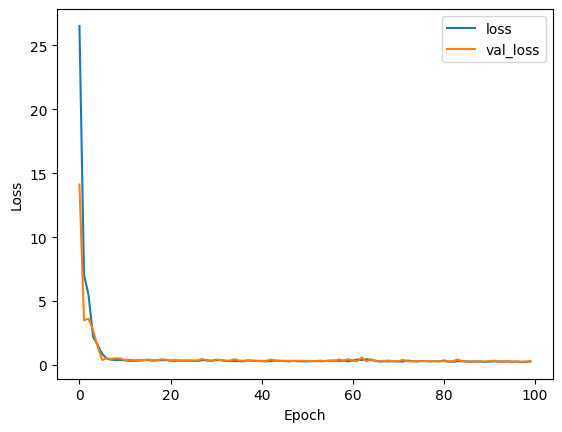

In [115]:
loss = history['loss']
mae = history['mae']
val_loss = history['val_loss']
val_mae = history['val_mae']

plt.plot(loss, label ='loss')
plt.plot(val_loss, label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()